In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as py

In [2]:
df = pd.read_csv(r"C:\Users\0106o\OneDrive\Pictures\Documents\Datasets\Youtube Project Files\youtube_clean.csv")
df['time'] = pd.to_datetime(df['time'])
df

,title,titleUrl,time,channelName,subscribed
0,Kubbi and Chumpatrol1 / Restoration of the Cairn,https://www.youtube.com/watch?v=cNz8GIDLn2A,2026-07-21 13:04:17.545000+00:00,Chumpatrol1,False
1,Kubbi - Pathfinder (Official Music Video),https://www.youtube.com/watch?v=EwNsnPfnIoU,2026-07-21 13:03:54.932000+00:00,Kubbi,True
2,Kubbi / Cascade,https://www.youtube.com/watch?v=B4ZjUoEKiLs,2026-07-21 13:03:50.258000+00:00,Kubbi,True
3,Kubbi / Pathfinder,https://www.youtube.com/watch?v=KRm2zCqwd1c,2026-07-21 13:03:31.732000+00:00,Kubbi,True
4,"ループザルーム feat. 初音ミク / ""Looping the Rooms"" ft. H...",https://www.youtube.com/watch?v=icBDYkfxpMs,2026-07-21 12:47:14.153000+00:00,ルシノ / rusino,True
...,...,...,...,...,...
26195,POWER OF [[NEO]] (BIG SHOT) :: Deltarune Chapt...,https://www.youtube.com/watch?v=mSppviwSUko,2025-02-17 00:48:13.926000+00:00,Geshtro,False
26196,Undertale - Mettaton NEO v2.0 (Fan-made),https://www.youtube.com/watch?v=0CteVubVnx8,2025-02-17 00:40:56.630000+00:00,A Huge Pancake,False
26197,"Undertale: Power of ""NEO"" (IKARUS Remix)",https://www.youtube.com/watch?v=uI0CxTgpA6Q,2025-02-17 00:38:41.966000+00:00,BlastProcessed,False
26198,Dançe Do Sonic (Baile Funk) [@fazomadeabangerr],https://www.youtube.com/watch?v=g-BWnNahE1I,2025-02-17 00:36:29.163000+00:00,fazomadeabanger*,True


In [3]:
#General Statistics
print("Number of videos in the dataset: " + str(len(df)))
print(f"Date range: {df['time'].min().date()} to {df['time'].max().date()}")
print(f"Total days covered: {(df['time'].max() - df['time'].min()).days}")
print(f"")

Number of videos in the dataset: 26200
Date range: 2025-02-17 to 2026-07-21
Total days covered: 519



In [4]:
#Q1 What percentage of my watched videos are from subscriptions
pct = (df['subscribed'].sum()/len(df))
print(f"{pct:.1%} of videos watched are from subscriptions")

21.8% of videos watched are from subscriptions


In [5]:
#Q2 Who are my top ten subscribed channels and who are my top 10 unsubscribed channels?

groupedSubbed = df[df['subscribed'] == True]['channelName']
groupedUnsubbed = df[df['subscribed'] == False]['channelName']


In [6]:
subbedGroup = groupedSubbed.value_counts().head(10)
subbedGroup

channelName
Korie Mckennedy        339
Zman G                 198
Hopeless Core          152
RabSoPetty             127
itsMonicaz             120
Legends of Avantris    110
Dmolition               93
YaBoyRoshi              91
Tony Statovci           89
The Anime Club          83
Name: count, dtype: int64

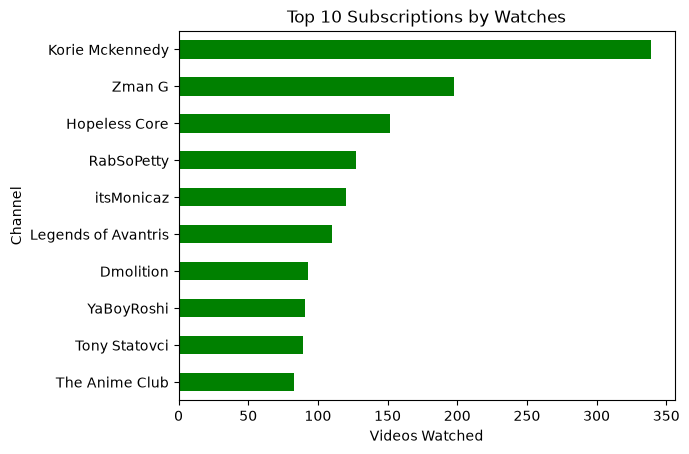

In [7]:
topSubbed = subbedGroup.plot.barh(color = "green")
topSubbed.invert_yaxis()
topSubbed.set_title('Top 10 Subscriptions by Watches')
topSubbed.set_ylabel('Channel')
topSubbed.set_xlabel('Videos Watched');

In [8]:
unSubbedGroup = groupedUnsubbed.value_counts().head(10)
unSubbedGroup

channelName
Mematus       293
Noeheather    223
nottaken      147
itsdondada    127
Rim Reaper     92
monium         91
K Prezzi       89
Viz            80
zulkxify       70
MrUnknown      69
Name: count, dtype: int64

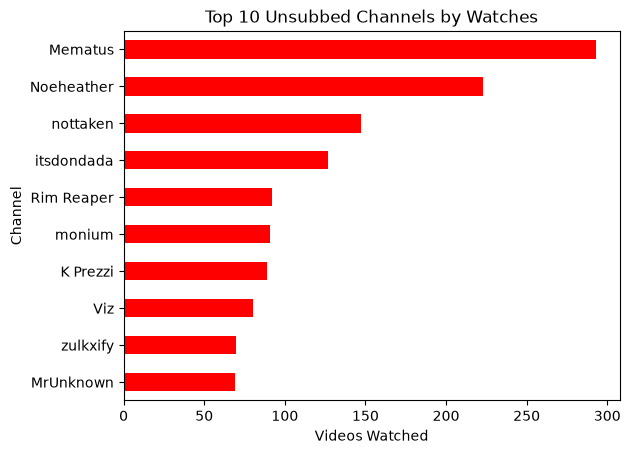

In [9]:
topUnsubbed = unSubbedGroup.plot.barh(color = "red")
topUnsubbed.invert_yaxis()
topUnsubbed.set_title('Top 10 Unsubbed Channels by Watches')
topUnsubbed.set_ylabel('Channel')
topUnsubbed.set_xlabel('Videos Watched');

In [10]:
#Q3 From my subscriptions, what is the average number of videos I've seen, the highest, and the lowest?
print("Average : " + f"{groupedSubbed.value_counts().mean(): .2f}")
print("Maximum : " + str(groupedSubbed.value_counts().max()))
print("Minimum: " + str(groupedSubbed.value_counts().min()))

Average :  10.28
Maximum : 339
Minimum: 1


In [11]:
#Q4A What is the average number of videos I watch per day and per month
byDay = df.groupby(df['time'].dt.date)
byMonth = df.groupby(df['time'].dt.to_period('M'))

print("Average per day : " + f"{byDay.size().mean(): .2f}")
print("Average per month : " + f"{byMonth.size().mean(): .2f}")

Average per day :  50.72
Average per month :  1454.11


C:\Users\0106o\AppData\Local\Temp\ipykernel_30340\3229204419.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  byMonth = df.groupby(df['time'].dt.to_period('M'))


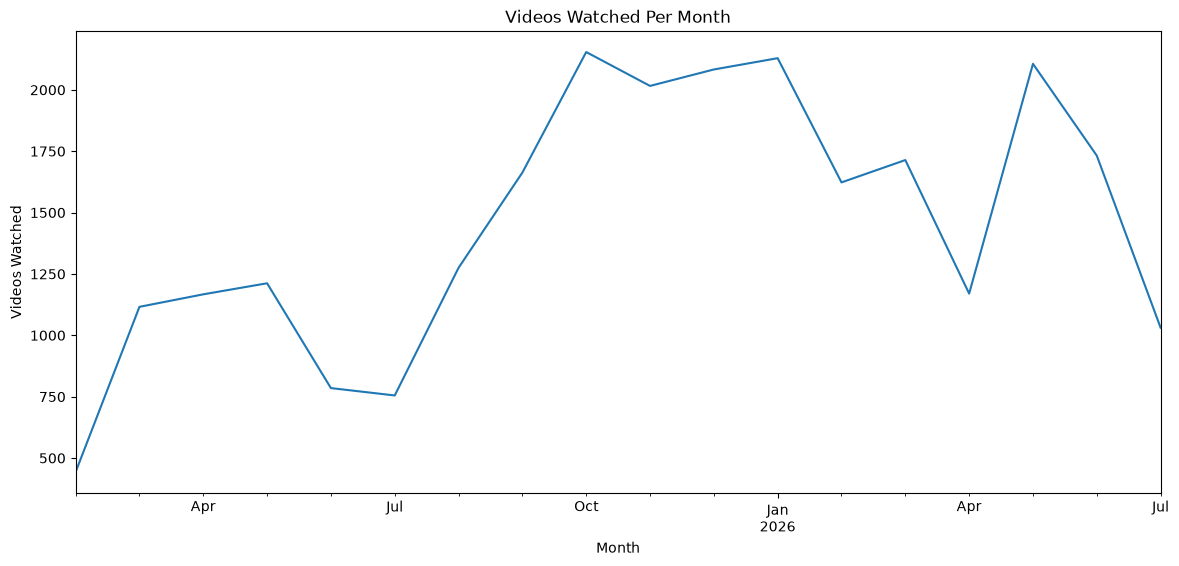

In [12]:
#Q4B Which months did I watch the most videos
plt.subplots(figsize=(14, 6))
monthLine = byMonth.size().plot()
plt.title("Videos Watched Per Month")
plt.xlabel("Month")
plt.ylabel("Videos Watched")
plt.show()
              

In [13]:
#Q5: Between my subscribed channels and unsubscribed channels, which ones have the longest title length on average?
#Creating a new column for title length to see the distribution of title lengths in my watch history
df['titleLength'] = df['title'].str.len()



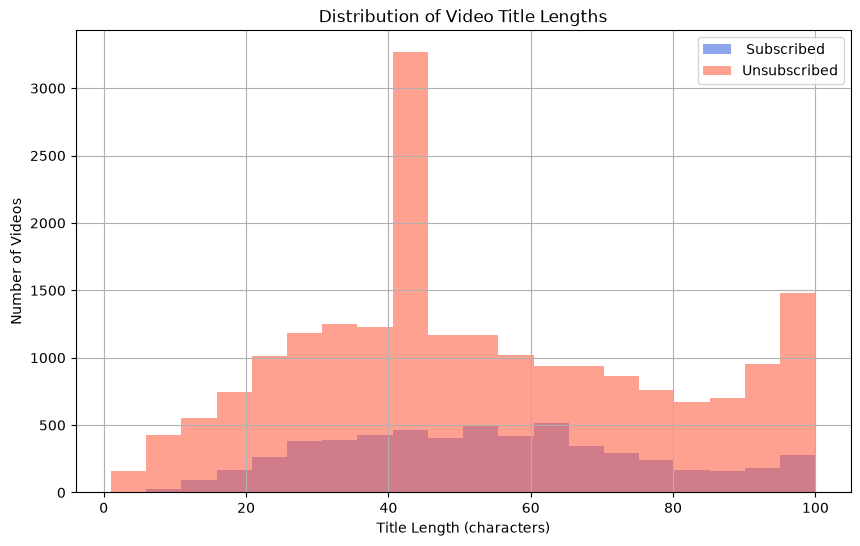

In [14]:
#Plotting the distribution in title length by subscribed channels and unsubscribed channels with a merged histogram
subLengths = df[df['subscribed'] == True]['titleLength']
unsubLengths = df[df['subscribed'] == False]['titleLength']

TitleLengthHist = subLengths.hist(bins=20, alpha=0.6, color= "royalblue", label=" Subscribed", figsize=(10, 6))
unsubLengths.hist(bins=20, alpha=0.6, color = "tomato", label="Unsubscribed", ax=TitleLengthHist)

TitleLengthHist.set_title("Distribution of Video Title Lengths")
TitleLengthHist.set_xlabel("Title Length (characters)")
TitleLengthHist.set_ylabel("Number of Videos")
TitleLengthHist.legend()

In [15]:
#Q6 What proportion of my subscriptions are above the average number of watches and what proportion are below?
subbedDF = df[df['subscribed'] == True]
subbedDF.drop('subscribed', axis = 1, inplace = True)


In [16]:
#Finding the average number of watches in the subscription set by channel to create categories
subbedWatches = subbedDF.groupby('channelName').size()
watchAverage = subbedWatches.mean()
watchMedian = subbedWatches.median()

#Printing the average and median watches of the set to see which is the more reliable statistic
print(watchAverage)
print(watchMedian)


10.282374100719425
3.0


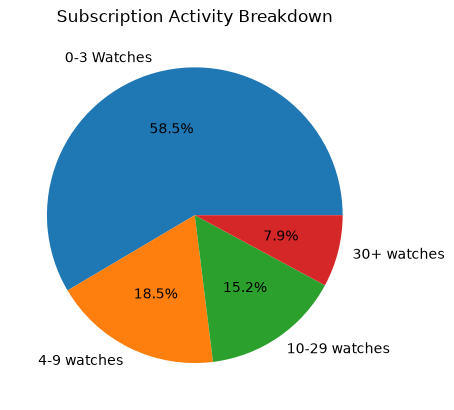

In [17]:
#Creating Categories and a pie chart corresponding to them
deadWatch = (subbedWatches <= 3).sum();
lowWatch = ((subbedWatches > 3) & (subbedWatches < 10)).sum()
moderateWatch = ((subbedWatches > 10) & (subbedWatches < 30)).sum()
highWatch = (subbedWatches >= 30).sum()

plt.pie([deadWatch, lowWatch, moderateWatch, highWatch], labels = ['0-3 Watches','4-9 watches', '10-29 watches', '30+ watches'], autopct="%1.1f%%")
plt.title("Subscription Activity Breakdown")
plt.show()


C:\Users\0106o\AppData\Local\Temp\ipykernel_30340\3835283272.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  timeGroups = df.groupby([df['time'].dt.to_period('M'), df['subscribed']]).size().unstack(fill_value = 0)


Text(0, 0.5, 'Videos Watched')

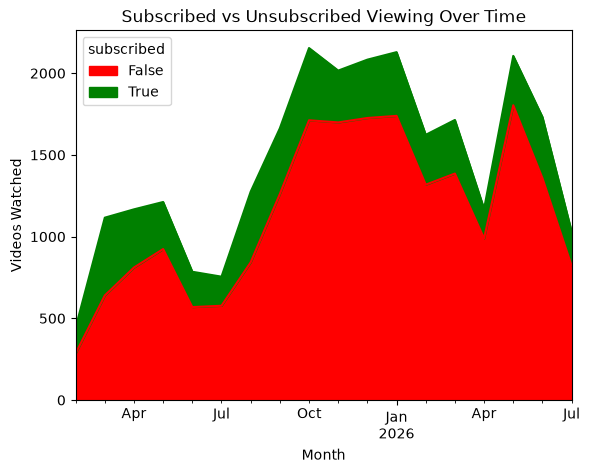

In [18]:
#Q7 How has my proportion of subscribed/unsubscribed watching changed over time?

timeGroups = df.groupby([df['time'].dt.to_period('M'), df['subscribed']]).size().unstack(fill_value = 0)
timePlot = timeGroups.plot.area(color = ['red', 'green'])
timePlot.set_title('Subscribed vs Unsubscribed Viewing Over Time')
timePlot.set_xlabel('Month')
timePlot.set_ylabel('Videos Watched')